In [ ]:
# Applied machine Learning Techniques



In [11]:
# importing ML libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Generating synthetic dataset
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()   

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Training a logistic regression model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# changing parameters of the model for better performance
model = LogisticRegression(C=0.5, solver='liblinear',max_iter=200,multi_class='ovr',random_state=42)
model.fit(X_train_scaled, y_train)




c:\Users\prern\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'ovr'


Accuracy: 0.88
Confusion Matrix:
[[85 15]
 [10 90]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       100
           1       0.86      0.90      0.88       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



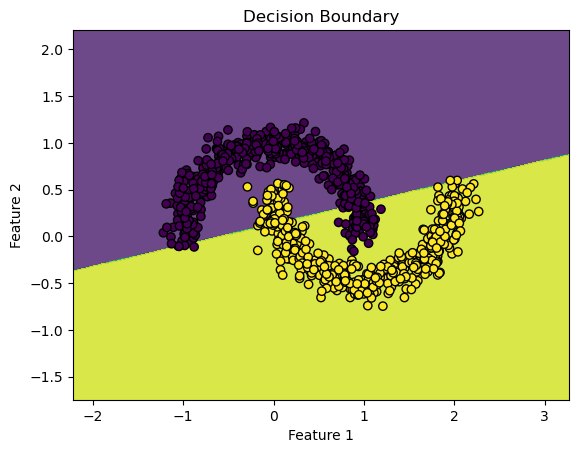

In [10]:

# Making predictions
y_pred = model.predict(X_test_scaled)
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
# Visualizing the decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
plot_decision_boundary(model, X, y)


SVM Accuracy: 1.00
SVM Confusion Matrix:
[[100   0]
 [  0 100]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



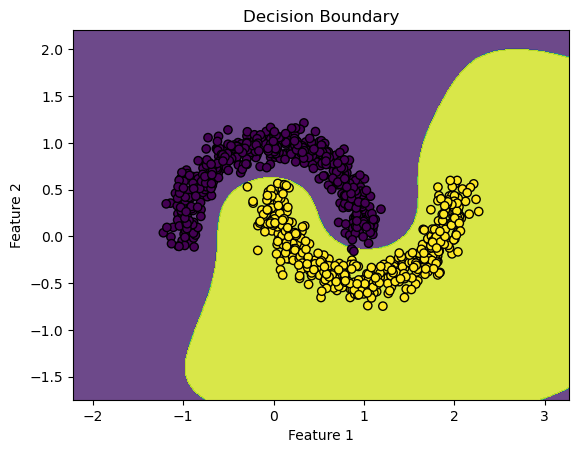

In [5]:
# Taking same dataset and applying a different model (e.g., Support Vector Machine)
from sklearn.svm import SVC
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)
class_report_svm = classification_report(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")
print("SVM Confusion Matrix:")
print(conf_matrix_svm)
print("SVM Classification Report:")
print(class_report_svm)
plot_decision_boundary(svm_model, X, y)


In [6]:
# check the SVM model's performance on the training data
y_train_pred_svm = svm_model.predict(X_train_scaled)
accuracy_train_svm = accuracy_score(y_train, y_train_pred_svm)
print(f"SVM Training Accuracy: {accuracy_train_svm:.2f}")

# check the SVM model's performance on the testing data
y_test_pred_svm = svm_model.predict(X_test_scaled)
accuracy_test_svm = accuracy_score(y_test, y_test_pred_svm)
print(f"SVM Testing Accuracy: {accuracy_test_svm:.2f}")



SVM Training Accuracy: 1.00
SVM Testing Accuracy: 1.00
